# Reproduce Figure 1(b) — 2D Phase Field Simulations

This notebook reproduces the four dynamical regimes from Figure 1(b) of
Goh et al., J. Chem. Phys. 163, 104905 (2025) using the **full 2D**
finite volume simulation.

Unlike the 1D radial reduction, the 2D simulation captures:
- Droplet elongation during directed motion
- Asymmetric morphologies (bean shapes)
- Vacuole formation
- True 2D concentration fields

**Regimes:**
- I. Dissolution
- II. Renucleation at promoter
- III. Directed motion
- IV. Directed motion with elongation

In [4]:
import os
import os.path
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec

# Add 2D source to path
sys.path.insert(0, str(Path('..') / 'src' / 'phasefield_2d'))

from config import SimulationConfig2D
from solvers.coupled_solver import CoupledSolver2D, classify_regime, compute_droplet_velocity

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## Simulation Parameters

From Figure 1(b) caption:
- α = 1, β = −0.25, κ = 0.05, χ = −0.1, γ = 0
- M_c = 1, D_m = 1, σ_p = 2.5, k_d = 1
- c+(t=0) = 5.5, m(r, t=0) = 0, r(t=0) = 10, R(t=0) = 2
- Varied: k_p and c−(t=0)

In [5]:
# Use smaller grid for faster execution; increase for publication quality
# Paper likely uses ~200x200 or finer
NX, NY = 200, 200
T_FINAL = 300.0

def run_regime(regime_name, config_fn, t_final=T_FINAL, nx=NX, ny=NY):
    """Run a single regime simulation."""
    config = config_fn()
    config.numerical.nx = nx
    config.numerical.ny = ny
    config.numerical.t_final = t_final
    config.numerical.save_interval = max(1, int(t_final / (config.numerical.dt * 50)))

    print(f"\n{'='*60}")
    print(f"Regime {regime_name}")
    print(f"  k_p = {config.transport.k_p}, c-(0) = {config.initial.c_minus_init}")
    print(f"  Grid: {nx} x {ny}, dt = {config.numerical.dt}")
    print(f"{'='*60}")

    solver = CoupledSolver2D(config)
    solver.initialize()
    history = solver.run()
    regime = classify_regime(history, config)
    print(f"Classified as Regime {regime}")
    return solver, history, regime

## Run All Four Regimes

In [5]:
# Regime I: Dissolution (k_p=0.05, c-=3.51)
solver_I, history_I, regime_I = run_regime(
    'I', SimulationConfig2D.figure_1b_regime_i, t_final=200.0)


Regime I
  k_p = 0.05, c-(0) = 3.51
  Grid: 200 x 200, dt = 0.001
Running 2D simulation: 200000 steps, dt=0.001, t_final=200.0
  Grid: 200 x 200, dx=0.2500, dy=0.2500
  Step 4000/200000 (t=4.00), ETA: 1328s, droplet at (10.00, 0.00), dist=10.00, R=2.93
  Step 8000/200000 (t=8.00), ETA: 1274s, droplet at (10.00, 0.00), dist=10.00, R=2.93
  Step 12000/200000 (t=12.00), ETA: 1278s, droplet at (10.01, 0.00), dist=10.01, R=2.90
  Step 16000/200000 (t=16.00), ETA: 1380s, droplet at (10.01, 0.00), dist=10.01, R=2.90
  Step 20000/200000 (t=20.00), ETA: 1431s, droplet at (10.01, 0.00), dist=10.01, R=2.86
  Step 24000/200000 (t=24.00), ETA: 1448s, droplet at (10.01, 0.00), dist=10.01, R=2.84
  Step 28000/200000 (t=28.00), ETA: 1460s, droplet at (10.01, 0.00), dist=10.01, R=2.84
  Step 32000/200000 (t=32.00), ETA: 1474s, droplet at (10.01, 0.00), dist=10.01, R=2.83
  Step 36000/200000 (t=36.00), ETA: 1466s, droplet at (10.01, 0.00), dist=10.01, R=2.81
  Step 40000/200000 (t=40.00), ETA: 1451s, d

In [11]:
 # Regime II: Renucleation (k_p=0.4, c-=3.51)
solver_II, history_II, regime_II = run_regime(
    'II', SimulationConfig2D.figure_1b_regime_ii, t_final=200.0)


Regime II
  k_p = 0.4, c-(0) = 3.51
  Grid: 200 x 200, dt = 0.001
Running 2D simulation: 200000 steps, dt=0.001, t_final=200.0
  Grid: 200 x 200, dx=0.2500, dy=0.2500
  Step 4000/200000 (t=4.00), ETA: 1227s, droplet at (10.01, 0.00), dist=10.01, R=2.92
  Step 8000/200000 (t=8.00), ETA: 2314s, droplet at (10.02, 0.00), dist=10.02, R=2.91
  Step 12000/200000 (t=12.00), ETA: 2936s, droplet at (10.04, -0.00), dist=10.04, R=2.88
  Step 16000/200000 (t=16.00), ETA: 3326s, droplet at (10.06, -0.00), dist=10.06, R=2.84
  Step 20000/200000 (t=20.00), ETA: 3541s, droplet at (10.08, 0.00), dist=10.08, R=2.82
  Step 24000/200000 (t=24.00), ETA: 3641s, droplet at (10.06, 0.00), dist=10.06, R=2.85
  Step 28000/200000 (t=28.00), ETA: 3654s, droplet at (9.48, 0.00), dist=9.48, R=2.95
  Step 32000/200000 (t=32.00), ETA: 3657s, droplet at (8.71, 0.00), dist=8.71, R=3.05
  Step 36000/200000 (t=36.00), ETA: 3591s, droplet at (8.05, 0.00), dist=8.05, R=3.13
  Step 40000/200000 (t=40.00), ETA: 3521s, dropl

In [14]:
# Regime III: Directed motion (k_p=0.08, c-=3.53)
solver_III, history_III, regime_III = run_regime(
    'III', SimulationConfig2D.figure_1b_regime_iii, t_final=T_FINAL)


Regime III
  k_p = 0.08, c-(0) = 3.53
  Grid: 200 x 200, dt = 0.001
Running 2D simulation: 300000 steps, dt=0.001, t_final=300.0
  Grid: 200 x 200, dx=0.2500, dy=0.2500
  Step 6000/300000 (t=6.00), ETA: 1625s, droplet at (10.00, 0.00), dist=10.00, R=2.99
  Step 12000/300000 (t=12.00), ETA: 1595s, droplet at (10.01, 0.00), dist=10.01, R=2.99
  Step 18000/300000 (t=18.00), ETA: 1557s, droplet at (10.01, -0.00), dist=10.01, R=2.99
  Step 24000/300000 (t=24.00), ETA: 1520s, droplet at (10.02, 0.00), dist=10.02, R=3.01
  Step 30000/300000 (t=30.00), ETA: 1487s, droplet at (10.02, 0.00), dist=10.02, R=3.01
  Step 36000/300000 (t=36.00), ETA: 1454s, droplet at (10.03, -0.00), dist=10.03, R=3.02
  Step 42000/300000 (t=42.00), ETA: 1420s, droplet at (10.03, 0.00), dist=10.03, R=3.02
  Step 48000/300000 (t=48.00), ETA: 1386s, droplet at (10.03, 0.00), dist=10.03, R=3.03
  Step 54000/300000 (t=54.00), ETA: 1355s, droplet at (10.03, 0.00), dist=10.03, R=3.03
  Step 60000/300000 (t=60.00), ETA: 13

In [15]:
# Regime IV: Directed motion + elongation (k_p=0.25, c-=3.60)
solver_IV, history_IV, regime_IV = run_regime(
    'IV', SimulationConfig2D.figure_1b_regime_iv, t_final=T_FINAL)


Regime IV
  k_p = 0.25, c-(0) = 3.6
  Grid: 200 x 200, dt = 0.001
Running 2D simulation: 300000 steps, dt=0.001, t_final=300.0
  Grid: 200 x 200, dx=0.2500, dy=0.2500
  Step 6000/300000 (t=6.00), ETA: 1626s, droplet at (10.01, 0.00), dist=10.01, R=3.24
  Step 12000/300000 (t=12.00), ETA: 1586s, droplet at (10.03, 0.00), dist=10.03, R=3.31
  Step 18000/300000 (t=18.00), ETA: 1553s, droplet at (10.05, 0.00), dist=10.05, R=3.36
  Step 24000/300000 (t=24.00), ETA: 1521s, droplet at (9.67, 0.00), dist=9.67, R=3.60
  Step 30000/300000 (t=30.00), ETA: 1486s, droplet at (8.88, 0.00), dist=8.88, R=3.80
  Step 36000/300000 (t=36.00), ETA: 1451s, droplet at (8.28, 0.00), dist=8.28, R=3.95
  Step 42000/300000 (t=42.00), ETA: 1418s, droplet at (7.81, 0.00), dist=7.81, R=4.09
  Step 48000/300000 (t=48.00), ETA: 1384s, droplet at (7.43, 0.00), dist=7.43, R=4.24
  Step 54000/300000 (t=54.00), ETA: 1351s, droplet at (7.11, 0.00), dist=7.11, R=4.36
  Step 60000/300000 (t=60.00), ETA: 1318s, droplet at 

## Visualize: Snapshots for All Regimes (Figure 1b style)

In [3]:
def plot_regime_snapshots(solver, history, regime_label, n_snapshots=5):
    """Plot protein concentration snapshots for a single regime."""
    grid = solver.grid
    extent = [-grid.Lx/2, grid.Lx/2, -grid.Ly/2, grid.Ly/2]

    indices = np.linspace(0, len(history)-1, n_snapshots, dtype=int)

    fig, axes = plt.subplots(1, n_snapshots, figsize=(3.5*n_snapshots, 3.5))
    if n_snapshots == 1:
        axes = [axes]

    c_all = np.array([history[i].c for i in indices])
    vmin, vmax = c_all.min(), c_all.max()

    for col, idx in enumerate(indices):
        state = history[idx]
        ax = axes[col]
        im = ax.imshow(state.c, extent=extent, origin='lower',
                       cmap='Blues', vmin=vmin, vmax=vmax, aspect='equal')
        ax.plot(0, 0, 'g*', markersize=8)
        ax.set_title(f't = {state.t:.0f}')
        ax.set_xlim(-15, 15)
        ax.set_ylim(-15, 15)
        if col > 0:
            ax.set_yticks([])

    fig.suptitle(f'Regime {regime_label}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

# Create images directory (relative path)
os.makedirs("../images", exist_ok=True)

fig_I = plot_regime_snapshots(solver_I, history_I, f'{regime_I} (Dissolution)')
fig_II = plot_regime_snapshots(solver_II, history_II, f'{regime_II} (Renucleation)')
fig_III = plot_regime_snapshots(solver_III, history_III, f'{regime_III} (Directed motion)')
fig_IV = plot_regime_snapshots(solver_IV, history_IV, f'{regime_IV} (Directed motion + elongation)')

# Save each regime figure separately
fig_I.savefig("../images/regime_I_snapshots.png", dpi=150, bbox_inches='tight')
fig_II.savefig("../images/regime_II_snapshots.png", dpi=150, bbox_inches='tight')
fig_III.savefig("../images/regime_III_snapshots.png", dpi=150, bbox_inches='tight')
fig_IV.savefig("../images/regime_IV_snapshots.png", dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'solver_I' is not defined

## Droplet Distance from Promoter vs Time

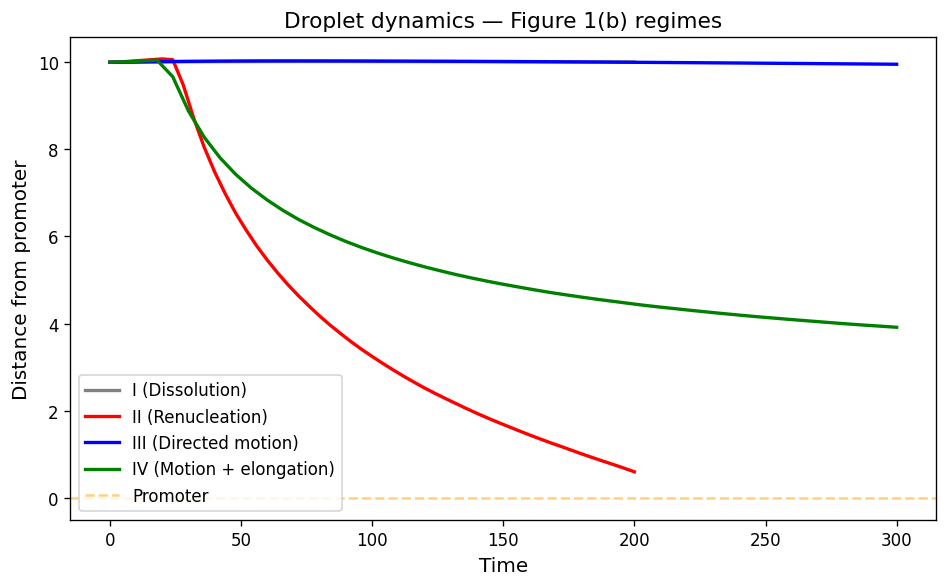

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

for label, hist, color in [
    ('I (Dissolution)', history_I, 'gray'),
    ('II (Renucleation)', history_II, 'red'),
    ('III (Directed motion)', history_III, 'blue'),
    ('IV (Motion + elongation)', history_IV, 'green')]:

    times = [s.t for s in hist]
    dists = []
    for s in hist:
        if s.droplet_center_x is not None:
            dists.append(np.sqrt(s.droplet_center_x**2 + s.droplet_center_y**2))
        else:
            dists.append(np.nan)
    ax.plot(times, dists, label=label, color=color, linewidth=2)

ax.axhline(0, color='orange', linestyle='--', alpha=0.5, label='Promoter')
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Distance from promoter', fontsize=12)
ax.set_title('Droplet dynamics — Figure 1(b) regimes', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Velocity vs Distance (Figure 1c)

The paper shows that the droplet velocity is non-monotonic in the distance
to the promoter, peaking when the leading edge touches the RNA source.

In [1]:
# Use Regime III for velocity analysis
distances, velocities = compute_droplet_velocity(history_III)

if len(distances) > 2:
    fig, ax = plt.subplots(figsize=(7, 5))
    v_max = np.max(np.abs(velocities))
    if v_max > 0:
        ax.plot(distances, velocities / v_max, 'b.-', linewidth=1.5)
    else:
        ax.plot(distances, velocities, 'b.-', linewidth=1.5)
    ax.set_xlabel('Distance from promoter (units of l)', fontsize=12)
    ax.set_ylabel('Velocity / max velocity', fontsize=12)
    ax.set_title('Droplet velocity vs distance — cf. Figure 1(c)', fontsize=13)
    ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('Not enough data points for velocity analysis')

NameError: name 'compute_droplet_velocity' is not defined

## Combined Protein + RNA Visualization

Shows both fields side by side at the final time for each regime.

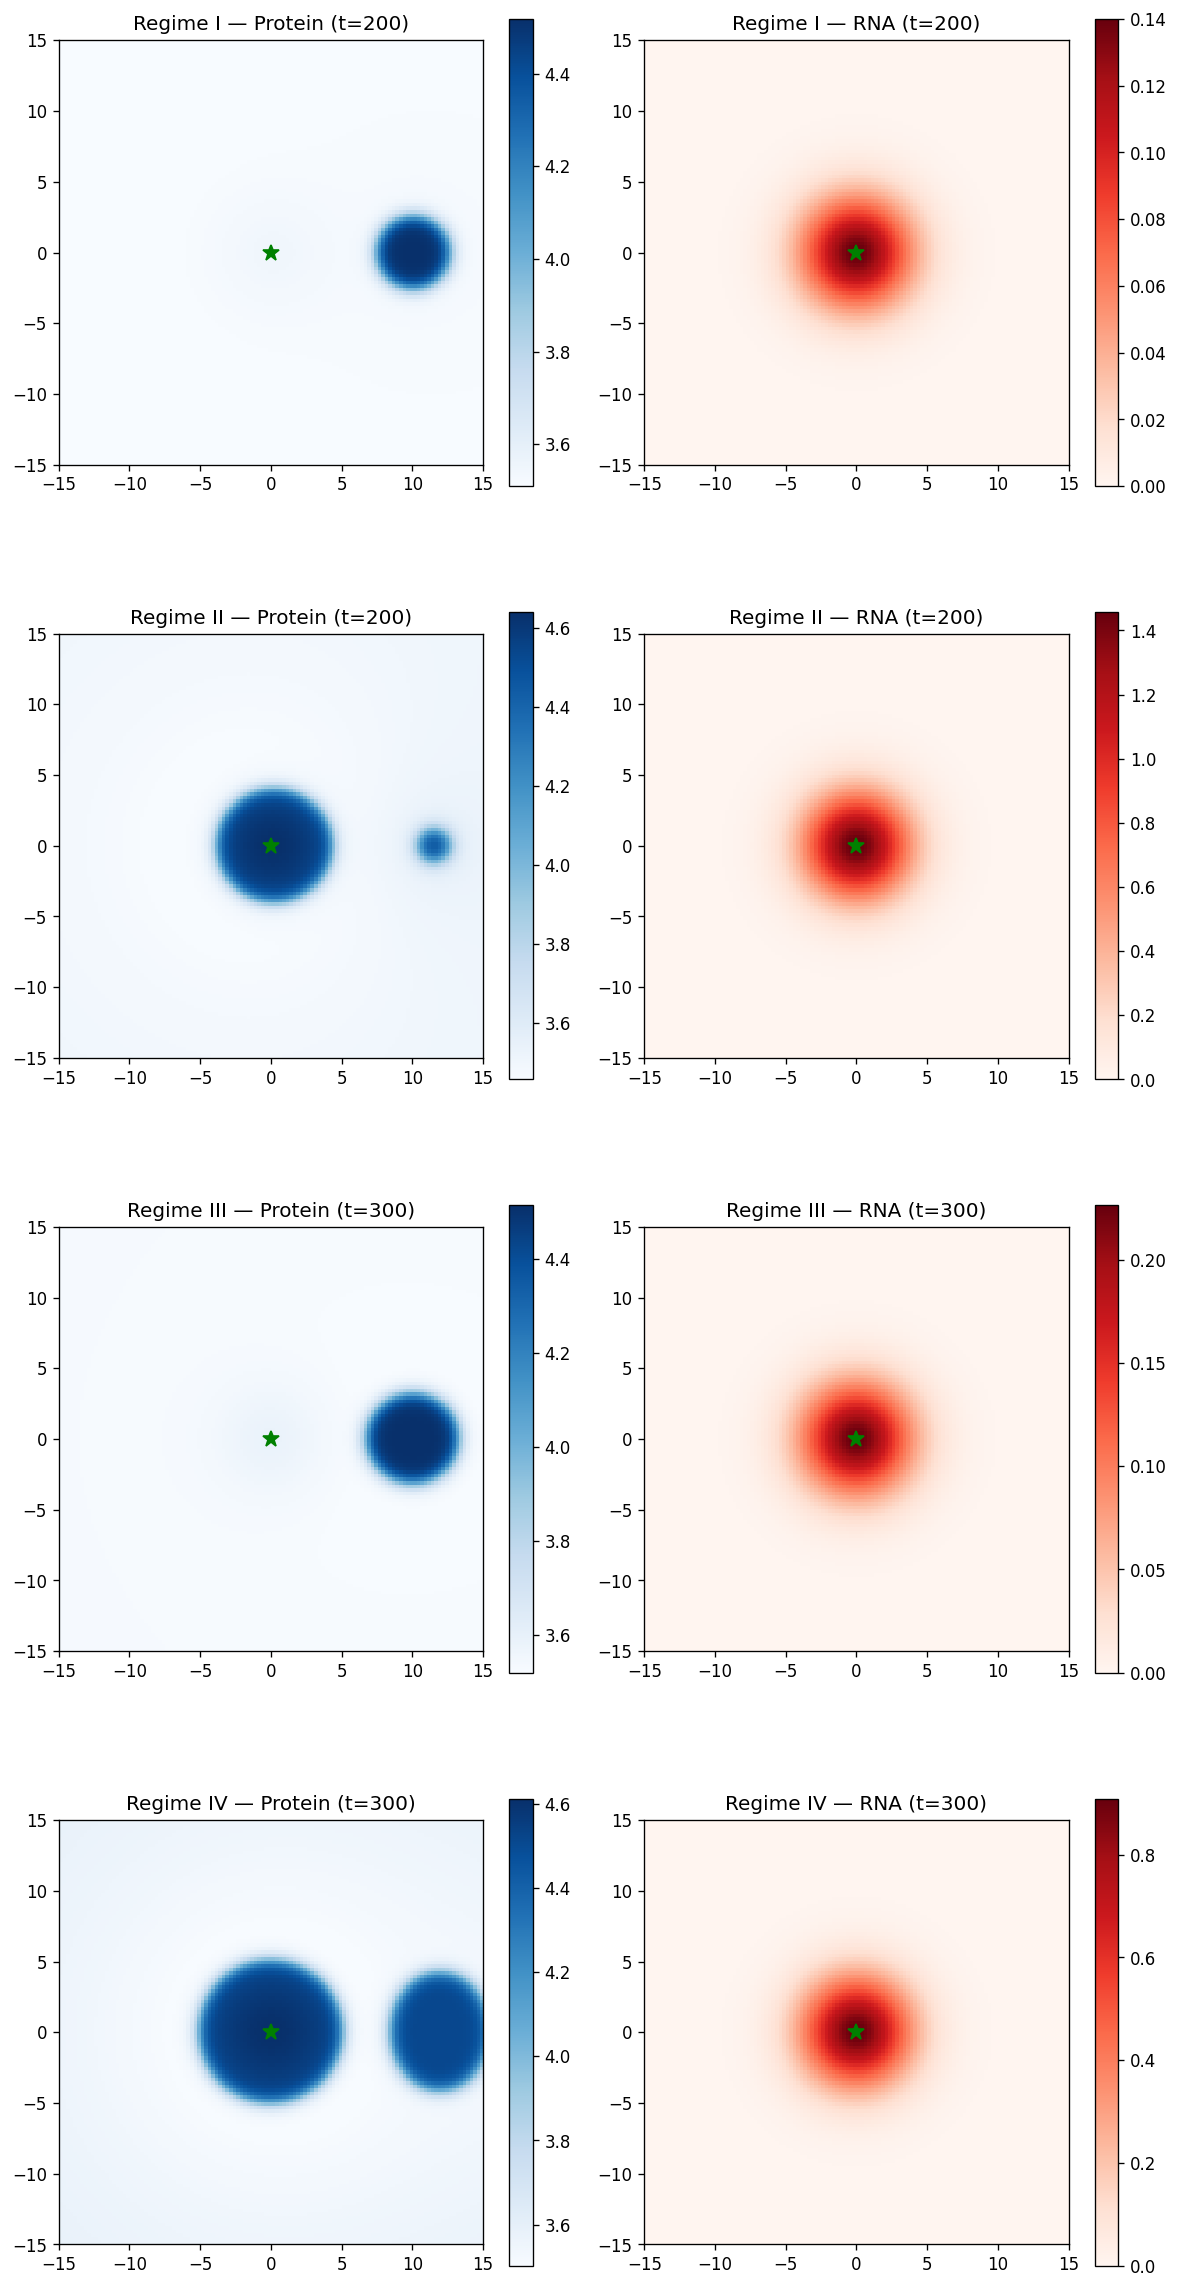

In [28]:
fig, axes = plt.subplots(4, 2, figsize=(10, 20))

for row, (label, solver, hist) in enumerate([
    ('I', solver_I, history_I),
    ('II', solver_II, history_II),
    ('III', solver_III, history_III),
    ('IV', solver_IV, history_IV)]):

    grid = solver.grid
    extent = [-grid.Lx/2, grid.Lx/2, -grid.Ly/2, grid.Ly/2]
    final = hist[-1]

    # Protein
    ax = axes[row, 0]
    im = ax.imshow(final.c, extent=extent, origin='lower', cmap='Blues', aspect='equal')
    ax.plot(0, 0, 'g*', markersize=10)
    ax.set_title(f'Regime {label} — Protein (t={final.t:.0f})')
    ax.set_xlim(-15, 15)
    ax.set_ylim(-15, 15)
    plt.colorbar(im, ax=ax, shrink=0.8)

    # RNA
    ax = axes[row, 1]
    im = ax.imshow(final.m, extent=extent, origin='lower', cmap='Reds', aspect='equal')
    ax.plot(0, 0, 'g*', markersize=10)
    ax.set_title(f'Regime {label} — RNA (t={final.t:.0f})')
    ax.set_xlim(-15, 15)
    ax.set_ylim(-15, 15)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()